In [1]:
from lcpy.calculators.bw_int import mpLCAer
import os
from lcpy.hvs.hvs import (store_scenario_results, create_scenario_dataframes, save_scenario_dataframes, create_and_save_dataframes_per_scenario_and_per_category, create_and_save_dataframes_time_series, visualize_dict_lineplots,
                          plot_bar_charts_by_category, visualize_stacked_barchart_time_series_impact, map_fcf_icf_results_to_flows,
                          plot_fcf_line_per_flow, plot_icf_line, plot_icf_line_per_flow, sum_scenarios_per_flow,
                          make_characterized_inventory_dfs)
from lcpy.calculators.env_calc import fast_calculator
from lcpy.hvs.map_dicts import create_mapping, create_list_with_unique_activities, store_dictionaries
import numpy as np
from lcpy.hvs.filling_dyn_cfs import calculate_fcf, calculate_icf

The workflow for performing a fully-dynamic LCA is the same as with the semi-dynamic LCA until the calculation of the unit_impacts and unit_inventories for the sub-sub-processes of each sub-process. The difference is on how we calculate later the impact of each environmental flow using dynamic characterization factors.

In [2]:
target_dir = "path_of_directory_where_to_store_results"
os.makedirs(target_dir, exist_ok=True)

In [3]:
brightway_configuration_dictionary = {
    "path_to_brightway_project": "path_to_folder_containing_the_bw_environment_and_packages_installed_there",
    "bw_project": "bw_project_name",
    "bw_database": "bw_project_database_name",
    "bw_biosphere": "bw_project_biosphere_database_name",
    "bw_ecoinvent": "ecoinvent_database_used_name"
}

In [4]:
methods_list = [
('TRACI v2.1', 'acidification', 'acidification potential (AP)'),
('TRACI v2.1', 'climate change', 'global warming potential (GWP100)'),
('TRACI v2.1', 'ecotoxicity: freshwater', 'ecotoxicity: freshwater'),
('TRACI v2.1', 'eutrophication', 'eutrophication potential'),
('TRACI v2.1', 'human toxicity: carcinogenic', 'human toxicity: carcinogenic'),
('TRACI v2.1', 'human toxicity: non-carcinogenic', 'human toxicity: non-carcinogenic'),
('TRACI v2.1', 'ozone depletion', 'ozone depletion potential (ODP)'),
('TRACI v2.1', 'particulate matter formation', 'particulate matter formation potential (PMFP)'),
('TRACI v2.1', 'photochemical oxidant formation', 'maximum incremental reactivity (MIR)'),
]

method_units_list = ['kg SO2-Eq',
 'kg CO2-Eq',
 'CTUe',
 'kg N-Eq',
 'CTUh',
 'CTUh',
 'kg CFC-11-Eq',
 'kg PM2.5-Eq',
 'kg O3-Eq',
]

In [5]:
methods_gp = methods_list[:]
impact_categories_names = ['AP', 'GWP100', 'ECFW', 'EP', 'HTC', 'HTNC', 'ODP', 'PMFP', 'MIR']

In [6]:
scenarios = 1
timeframe = 10 #operational lifetime after construction
time_step = 1
construction_years = 1
number_of_infrastructure_processes = 1

In [7]:
bwr_growth = (1. + 0.02)
pwr_growth = (1. - 0.01)
hydro_growth = (1. + 0.01)
dge_growth = (1. + 0.04)
wind_growth = (1. + 0.02)

In [8]:
NG_ccpp_capacity = np.full((scenarios, timeframe // time_step), 400.)
NG_convpp_capacity = NG_ccpp_capacity*0.1

BWR_capacity = np.zeros((scenarios, timeframe // time_step))
PWR_capacity = np.zeros((scenarios, timeframe // time_step))
Hydro_pumped_capacity = np.zeros((scenarios, timeframe // time_step))
DGE_capacity = np.zeros((scenarios, timeframe // time_step))

Wind_1_3_capacity = np.zeros((scenarios, timeframe // time_step))
NG_cogen_cc_capacity = np.full((scenarios, timeframe // time_step), 230.)
NG_cogen_conv_capacity = np.full((scenarios, timeframe // time_step), 1100.)
for i in range(scenarios):
    for j in range(timeframe // time_step):
        BWR_capacity[i, j] = 1500*(bwr_growth**j)
        PWR_capacity[i, j] = 800*(pwr_growth**j)
        Hydro_pumped_capacity[i, j] = 420*(hydro_growth**j)
        DGE_capacity[i, j] = 85*(dge_growth**j)
        Wind_1_3_capacity[i,j] = 980*(wind_growth**j)

In [9]:
total_capacity = BWR_capacity + PWR_capacity + NG_ccpp_capacity + NG_cogen_conv_capacity + NG_convpp_capacity + NG_cogen_cc_capacity + Hydro_pumped_capacity + DGE_capacity + Wind_1_3_capacity

In [10]:
bwr_share = BWR_capacity / total_capacity
pwr_share = PWR_capacity / total_capacity
ng_ccpp_share = NG_ccpp_capacity / total_capacity
ng_cogen_share = NG_cogen_conv_capacity / total_capacity
ng_convpp_share = NG_convpp_capacity / total_capacity
ng_cogen_cc_share = NG_cogen_cc_capacity / total_capacity
hydro_share = Hydro_pumped_capacity / total_capacity
dge_share = DGE_capacity / total_capacity
wind_share = Wind_1_3_capacity / total_capacity

In [11]:
butanol_consumption = np.full((scenarios, timeframe // time_step), 80.)
other_chemical_consumption = np.ones((scenarios, timeframe // time_step))

In [12]:
for i in range(scenarios):
    for j in range(timeframe // time_step):
        other_chemical_consumption[i, j] = 40. + (40. * 0.01*j)

In [13]:
total_fu = np.full((scenarios, timeframe // time_step), 1.)

In [14]:
for i in range(scenarios):
    for j in range(timeframe // time_step):
        total_fu[i, j] = 50. + (30. * 0.05*j)

In [15]:
total_fu = total_fu

In [16]:
waste_material = butanol_consumption + other_chemical_consumption - total_fu

In [17]:
total_fu = [total_fu]

In [18]:
building = np.full((scenarios, construction_years),1.)

In [19]:
keys_infrastructure = {
    'Building' : 'bw_key_pointing_to_relevant_process'
}

infrastructure_exchanges_amounts = [
    building
]

In [20]:
keys_electricity_consumption = {
'PWR' :  'bw_key_pointing_to_relevant_process',
'BWR' : 'bw_key_pointing_to_relevant_process',
'NG_ccpp' :  'bw_key_pointing_to_relevant_process',
'NG_convpp' : 'bw_key_pointing_to_relevant_process',
'NG_cogen_conv' :  'bw_key_pointing_to_relevant_process',
'NG_cogen_cc' : 'bw_key_pointing_to_relevant_process',
'Hydro' :  'bw_key_pointing_to_relevant_process',
'DGE' : 'bw_key_pointing_to_relevant_process',
'Wind' :  'bw_key_pointing_to_relevant_process',
}

electricity_exchanges_amounts = [
    pwr_share*500,
    bwr_share*500,
    ng_ccpp_share*500,
    ng_convpp_share*500,
    ng_cogen_share*500,
    ng_cogen_cc_share*500,
    hydro_share*500,
    dge_share*500,
    wind_share*500,
]

keys_chemical_consumption = {
    'butanol': 'bw_key_pointing_to_relevant_process',
    'other chemical': 'bw_key_pointing_to_relevant_process'
}

chemicals_exchanges_amounts = [
    butanol_consumption,
    other_chemical_consumption,
]

keys_waste = {
    'Solid waste': 'bw_key_pointing_to_relevant_process'
}

waste_exchanges_amounts = [
    -waste_material
]

In [21]:
keys_main_process = {
'Infrastructure': '',
'Electricity consumption': '',
'Chemical consumption' :  '',
'Waste handling' :  '',
}

mp_exchanges_amounts = [
1./(50*50000*1000) * np.full((scenarios, timeframe // time_step),1.),
np.full((scenarios, timeframe // time_step),1.),
np.full((scenarios, timeframe // time_step),1.),
np.full((scenarios, timeframe // time_step),1.),
]

In [22]:
key_list_sub_processes = [keys_infrastructure, keys_electricity_consumption, keys_chemical_consumption, keys_waste]

exchanges_list_sub_processes = [infrastructure_exchanges_amounts, electricity_exchanges_amounts, chemicals_exchanges_amounts,
                                      waste_exchanges_amounts]

In [23]:
mapping_names = create_mapping(keys_main_process, key_list_sub_processes)

In [24]:
unique_activities = create_list_with_unique_activities(key_list_sub_processes)

In [25]:
mapping_exchanges = create_mapping(keys_main_process, exchanges_list_sub_processes)

In [26]:
my_lca = mpLCAer(6, methods_gp, brightway_configuration_dictionary)

In [27]:
my_lca.import_isolated_environment()

In [28]:
my_lca.lca_calculations(mapping_names)

We derive the technospere and biosphere dictionaries of random processes and ensure they are the same (optional). We can set the number of processes to check. Then we can store them in an excel file that can be used later to input the dynamic CFs.

In [29]:
my_lca.derive_technosphere_and_biosphere_dictionaries(mapping_names, "Main process")

All biosphere dictionaries are the same
All technosphere dictionaries are the same


In [30]:
store_dictionaries(my_lca.biosphere_dict['Main process'], target_dir, 'Biosphere_Flows.xlsx')
store_dictionaries(my_lca.technosphere_dict['Main process'], target_dir, 'Technosphere_Flows.xlsx')

We define a fast calculator instance

In [31]:
my_calculator = fast_calculator()

To make the dynamic characterization we need to play with the environmental flows. This is the reason we play with the unit_inventory and characterized inventory calculated from bw.

We first sum for each sub_process each amount of environmental flow emitted by each sub-sub-process. This is input in an array the row of which follows the biosphere_dict!

Second, we do the same for the characterized inventories.

In [32]:
my_calculator.sum_inventory_per_sub_sub_process(my_lca.unit_inventory)

In [33]:
my_calculator.sum_characterized_inventory_per_sub_sub_process(my_lca.unit_char_inventory)

We now scale the unit inventory of each sub-sub-process included in each sub-process with the exchange amounts needed in each sub-process

In [34]:
my_calculator.emissions_calculation_in_time(mapping_exchanges, my_calculator.summed_unit_inventories)

We do the same for the unit characterized inventory of each sub-sub-process included in each sub-process with the exchange amounts needed in each sub-process

In [35]:
my_calculator.characterized_inventory_calculation_in_time(mapping_exchanges, my_calculator.summed_unit_characterized_inventories)

And now we scale the unit inventory of each sub-process with the exchange amounts needed for the main process. We calculate thus the unit inventory for the main process. We do the same for the characterized inventory for each impact category.

In [36]:
my_calculator.emissions_calculation_in_time_total(mp_exchanges_amounts, my_calculator.inventory, number_of_infrastructure_processes, construction_years, "Main process" )

In [37]:
my_calculator.characterized_inventory_calculation_in_time_total(mp_exchanges_amounts, my_calculator.characterized_inventory, number_of_infrastructure_processes, construction_years, "Main process")

At this point we have calculated the unit inventory for each sub-process and the unit inventory for the main process. Also, we have calculated the
unit characterized inventory for each sub-process and for the main process. The make_characterized_inventory_dfs function can be used to create a dictionary that holds for a scenario and for each impact category in this scenario dataframes of dimensions (flows, time_steps) that hold the characterized inventory for this impact category for each environmental flow. These dataframes can be used to investigate the impact per flow. This function can be run also for the unit_characterized_inventory of each sub-process as well. There are also dictionaries that hold the contribution of each sub-process (for the main process) to each environmental flow and also dictionaries that hold the contribution of each sub-sub-process (for each sub-process) to each environmental flow.

In [38]:
dictionary_with_dfs_per_environmental_flow_mp = make_characterized_inventory_dfs(my_calculator.total_char_inventory['Main process'],
                                        impact_categories_names, my_lca.biosphere_dict['Main process'],
                                        0)

In [39]:
dictionary_with_dfs_per_environmental_flow_elec_cons = make_characterized_inventory_dfs(my_calculator.characterized_inventory['Electricity consumption'],
                                        impact_categories_names, my_lca.biosphere_dict['Main process'],
                                        0)

The characterized inventories (and the impact dictionaries that were demonstrated in the semi-dynamic LCA example) use static CFs. Below we present a fully dynamic analysis that uses dynamic CFs. We can load the dynamic CFs directly as in the cell below or use the calculate_fcf and calculate_icf functions to create them. Instructions on how to create these numpy arrays are given in the technical documentation. Lcpy does not provide functions to calculate the dyn CFs but only the way to use them. Some dynCFs for the GWP are provided based on a previous paper. The analysis below concerns only the GWP for which dyn CFs are available. For another impact category the functions should be repeated.

In [40]:
dyn_factors_gwp_100_fcf = np.load('path_to_numpy_arrays_holding_dynamic_FCF_characterization_factors')
dyn_factors_gwp_100_icf = np.load('path_to_numpy_arrays_holding_dynamic_ICF_characterization_factors')

In [41]:
dyn_factors_gwp_100_fcf = calculate_fcf("path_to_excel_files_holding_the_initial_factors_that_are_to_be_used_for_the_calculation_of_the_FCFs",
                                        "GWP-FCF", methods_gp[1], "gwp100", return_array=True, configuration_dictionary = brightway_configuration_dictionary)
dyn_factors_gwp_100_icf = calculate_icf("path_to_excel_files_holding_the_initial_factors_that_are_to_be_used_for_the_calculation_of_the_FCFs",
                                        "GWP-ICF", methods_gp[1], "gwp100", return_array=True, configuration_dictionary =  brightway_configuration_dictionary)

And below we calculate the impact with FCF and ICF dynamic characterization factors. We do this for the main process (total_inventory), but it can be done for the sub-processes separately as well.

In [42]:
my_calculator.calculation_dynamic_LCIA_fcf(my_calculator.total_inventory['Main process'], dyn_factors_gwp_100_fcf, 'GWP')

In [43]:
my_calculator.calculation_dynamic_LCIA_icf(my_calculator.total_inventory['Main process'], dyn_factors_gwp_100_icf, 'GWP')

We have now calculated the impact with the dynamic impact assessment methods. We now run the same functions as those described in the semi_dynamic LCA example to exploit these results and calculate the impact per scenario, per fu, evolution of the impact in time etc. and save these results.

In [44]:
my_calculator.calculate_total_impact_per_category_and_scenario_fcf('GWP')

In [45]:
my_calculator.calculate_total_fu_per_scenario(total_fu,'Main process')

In [46]:
my_calculator.per_fu_per_category_per_scenario_fcf('GWP', 'Main process')

In [47]:
my_calculator.calculation_of_the_in_time_impact_evolution_absolute_fcf('GWP')

In [48]:
my_calculator.cum_calculation_of_the_in_time_impact_evolution_per_fu_actual_fcf('GWP', construction_years, 'Main process')

In [49]:
scenario_names = [str(i) for i in range(scenarios)]

In [50]:
dict_total_impact_fcf = create_scenario_dataframes(my_calculator.total_impact_fcf['GWP'], ['GWP100'], scenario_names)

In [51]:
dict_total_impact_per_fu_fcf = create_scenario_dataframes(my_calculator.cum_impact_in_time_per_fu_fcf['GWP'], ['GWP100'], scenario_names)

In [52]:
scenario_dict_cum_impact_fcf = create_scenario_dataframes(my_calculator.cum_impact_in_time_fcf['GWP'], ['GWP100'], scenario_names)

In [53]:
df_impact_per_category_and_scenario_fcf_gwp = create_and_save_dataframes_per_scenario_and_per_category(my_calculator.total_impact_per_category_and_scenario_fcf['GWP'], ['GWP'], os.path.join(target_dir, 'impact_per_category_per_scenario_fcf_gwp.xlsx'))

Dataframes not save, set save to True to save them


In [54]:
df_impact_per_fu_category_and_scenario_fcf_gwp = create_and_save_dataframes_per_scenario_and_per_category(my_calculator.total_impact_per_fu_per_category_per_scenario_fcf['GWP'], ['GWP'], os.path.join(target_dir, 'impact_per_fu_category_per_scenario_fcf.xlsx'))

Dataframes not save, set save to True to save them


In [55]:
dataframes_total_impact_fcf_gwp = create_and_save_dataframes_time_series(my_calculator.total_impact_fcf['GWP'], ['GWP'], scenario_names, excel_file_name= os.path.join(target_dir, 'impacts_time_series_fcf_gwp.xlsx'))

Dataframes not save, set save to True to save them


In [56]:
dataframes_cum_impact_fcf_gwp = create_and_save_dataframes_time_series(my_calculator.cum_impact_in_time_fcf['GWP'], ['GWP'], scenario_names, excel_file_name= os.path.join(target_dir, 'cum_impacts_time_series_fcf_gwp.xlsx'))

Dataframes not save, set save to True to save them


In [57]:
dataframes_cum_impact_per_fu_fcf_gwp = create_and_save_dataframes_time_series(my_calculator.cum_impact_in_time_per_fu_fcf['GWP'], ['GWP'], scenario_names, excel_file_name= os.path.join(target_dir, 'cum_impacts_per_fu_time_series_fcf_gwp.xlsx'))

Dataframes not save, set save to True to save them


In [58]:
store_scenario_results(df_impact_per_category_and_scenario_fcf_gwp, target_dir, method_units_list, (5,3), 300, 'Main process FCF')

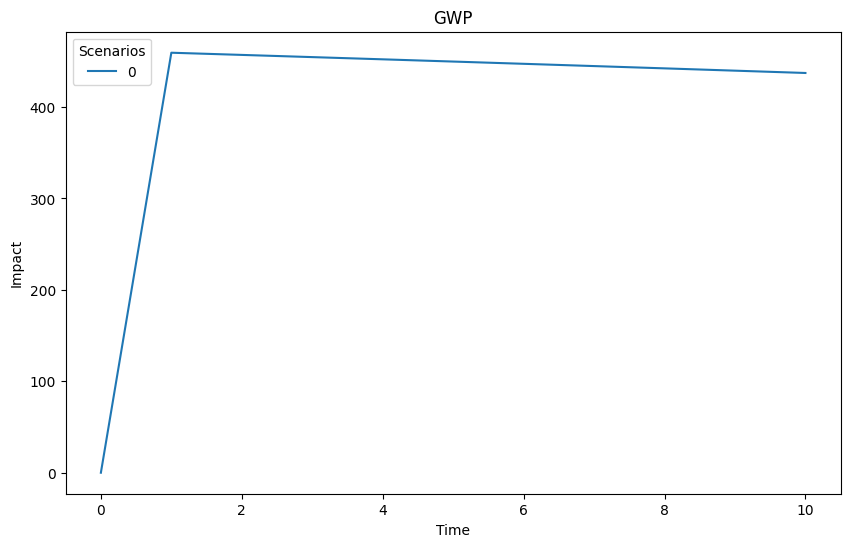

In [59]:
dict_total_impact_per_category_fcf_gwp_graphite = visualize_dict_lineplots(dataframes_total_impact_fcf_gwp, ['GWP'], target_dir, keys_to_plot = ['GWP'], scenarios_to_plot = ['0'], name = 'FCF_gwp_main_process')

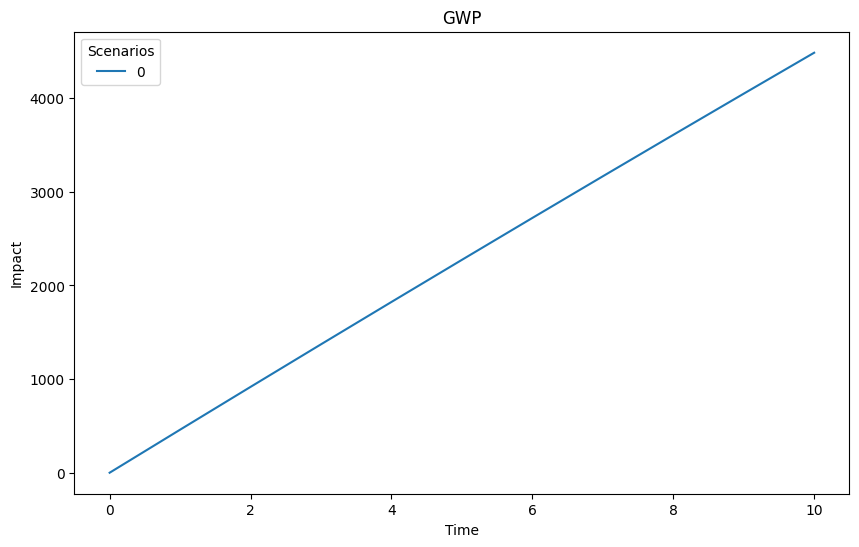

In [60]:
dict_cum_impact_per_category_fcf_gwp = visualize_dict_lineplots(dataframes_cum_impact_fcf_gwp, ['GWP'], target_dir, keys_to_plot = ['GWP'], scenarios_to_plot = ['0'], name = 'FCF_gwp_main_process')

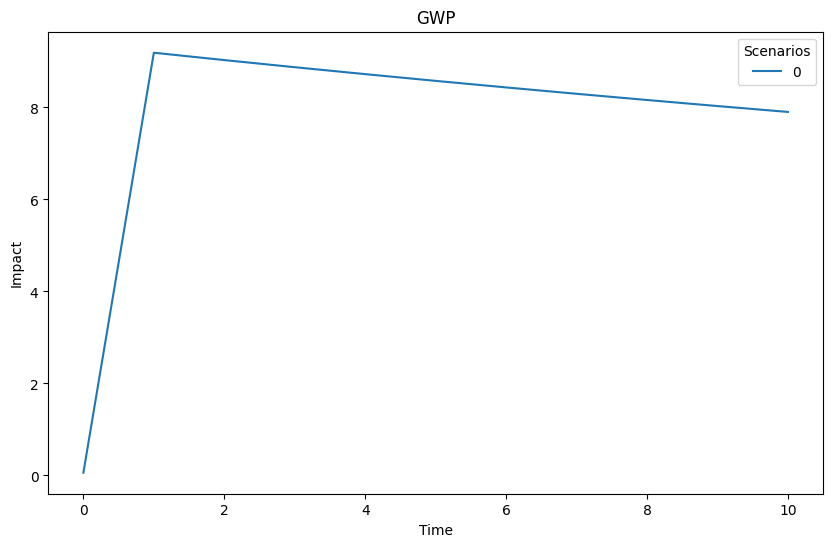

In [61]:
dict_cum_impact_per_fu_per_category_fcf_gwp = visualize_dict_lineplots(dataframes_cum_impact_per_fu_fcf_gwp, ['GWP'], target_dir, keys_to_plot = ['GWP'], scenarios_to_plot = ['0'], name = 'FCF_gwp_main_process')

In [62]:
scenario_dict_total_impact_fcf_gwp = create_scenario_dataframes(my_calculator.total_impact_fcf['GWP'], ['GWP'], scenario_names)

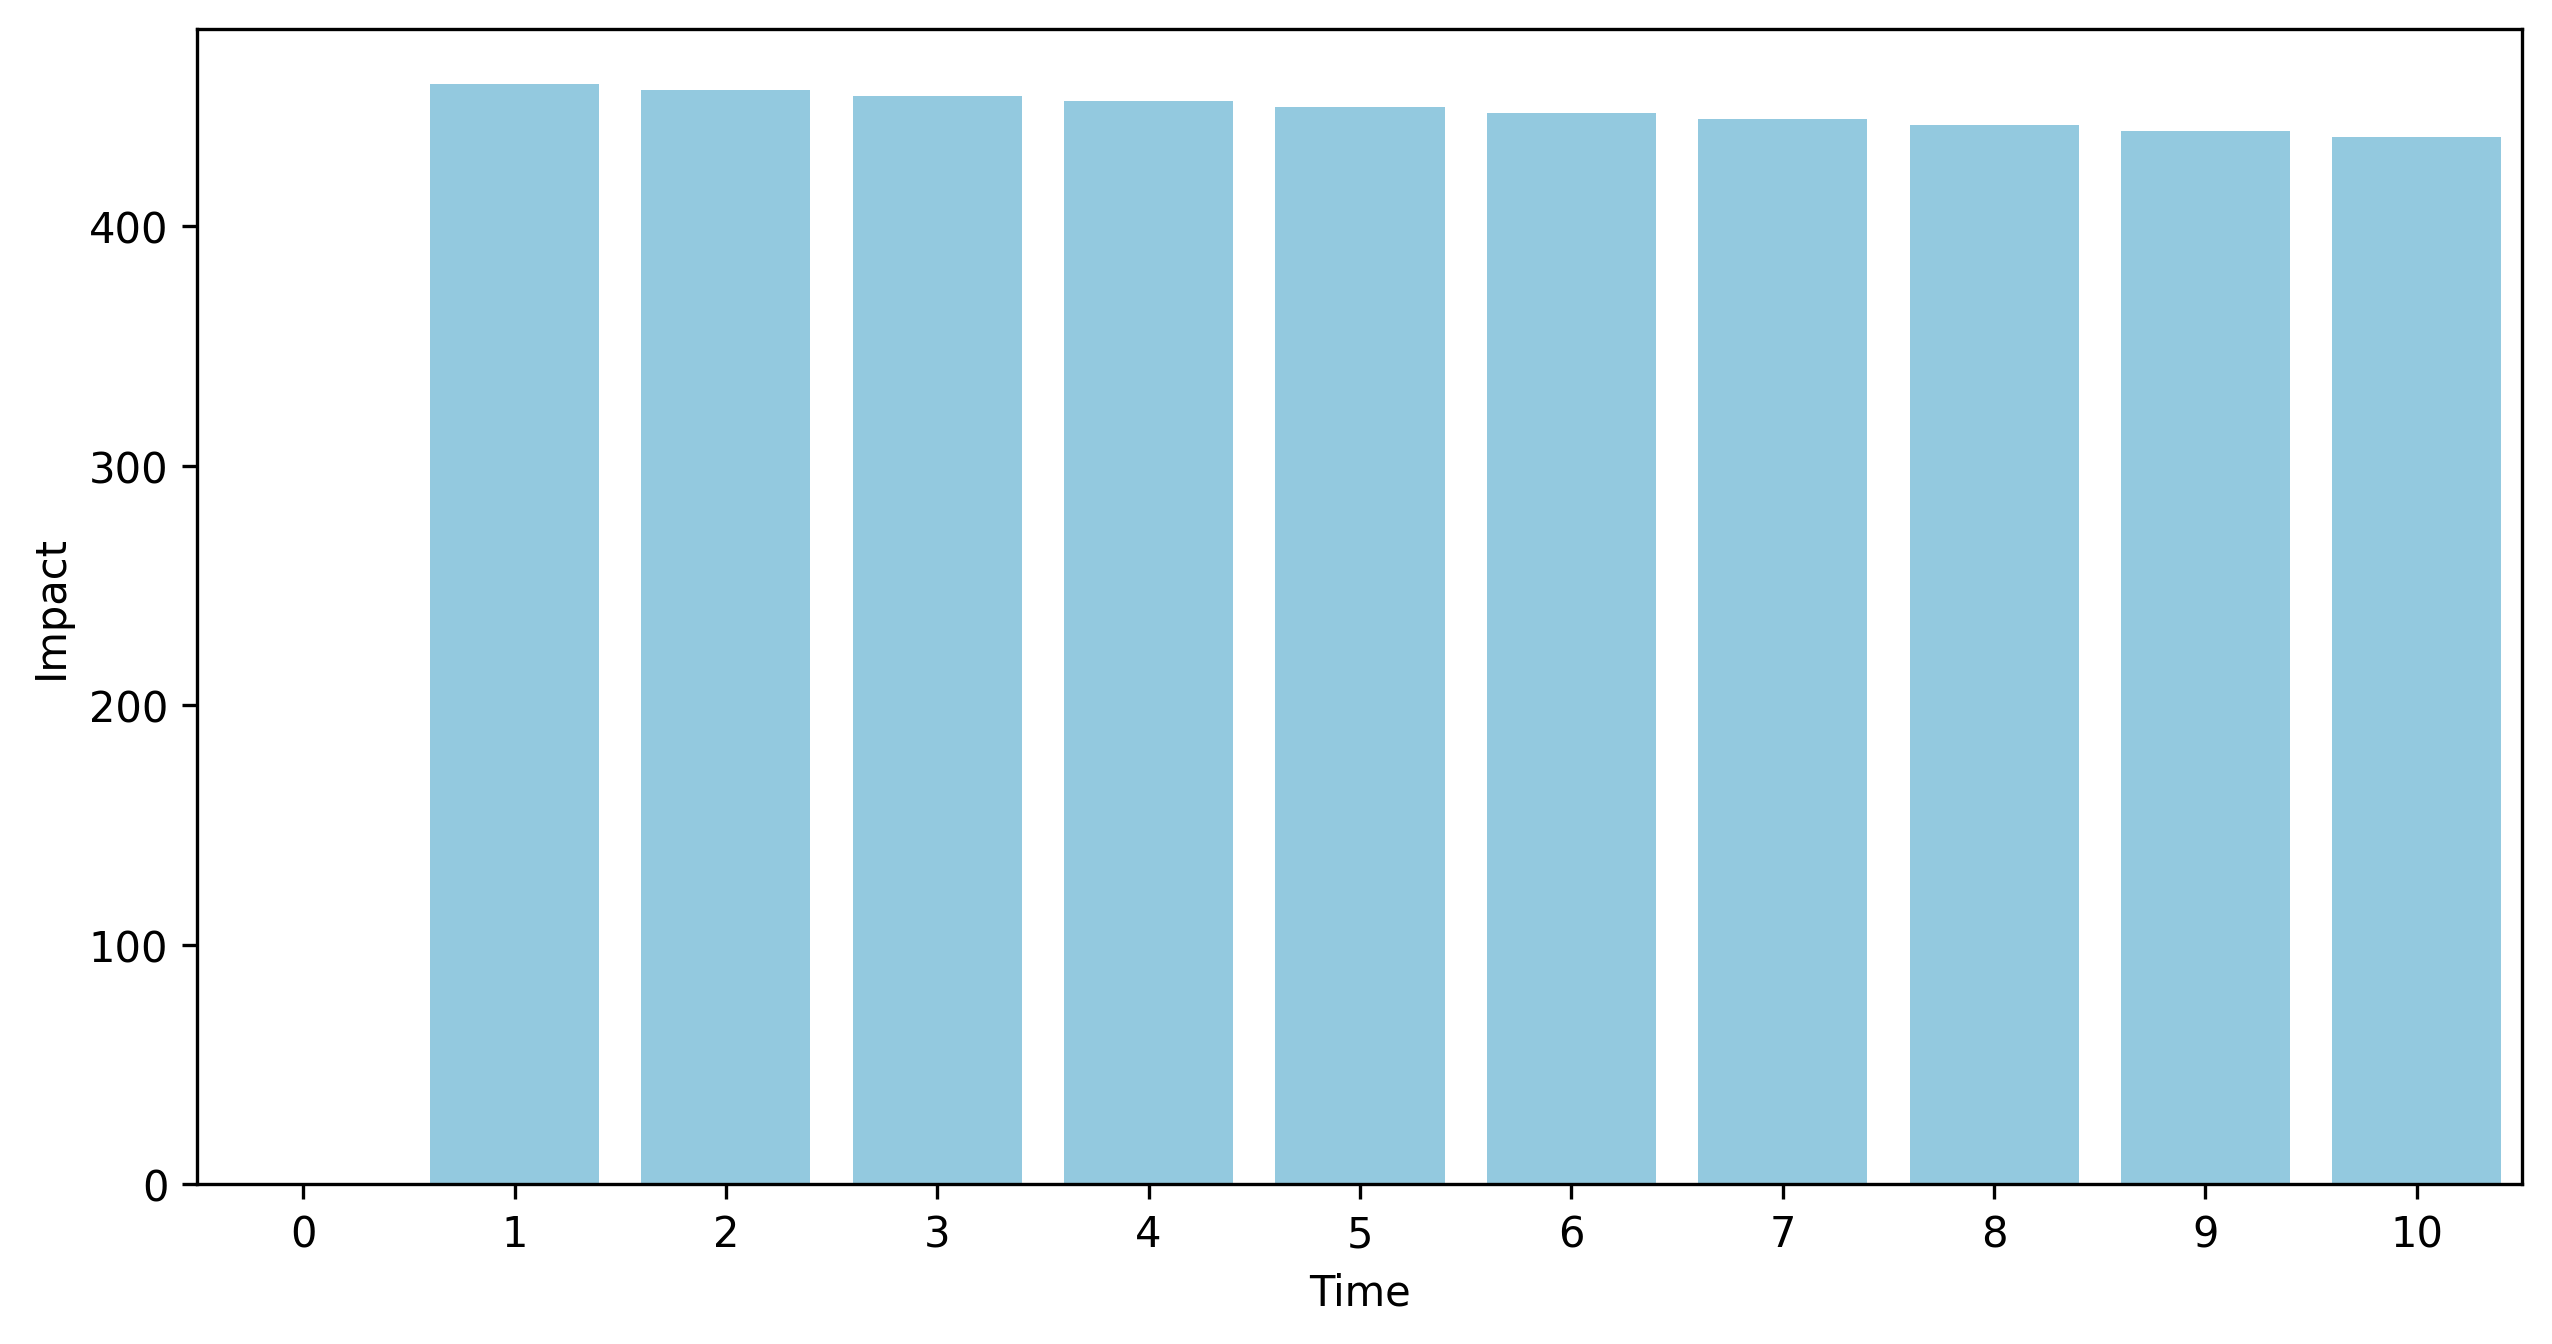

Plot saved: C:\Users\sgkousis\Desktop\Example_results\Results_fully_dynamic\0_barplot_GWP100_fcf_gwp_main_process_.png


In [63]:
plot_bar_charts_by_category(dict_total_impact_fcf, scenarios_to_plot= ['0'],impacts_to_plot = ['GWP100'], target_dir = target_dir, name = 'fcf_gwp_main_process')

In [64]:
my_dict_fcf_flow = map_fcf_icf_results_to_flows(my_lca.biosphere_dict['Main process'], scenario_names, my_calculator.total_impact_fcf_per_flow['GWP'])

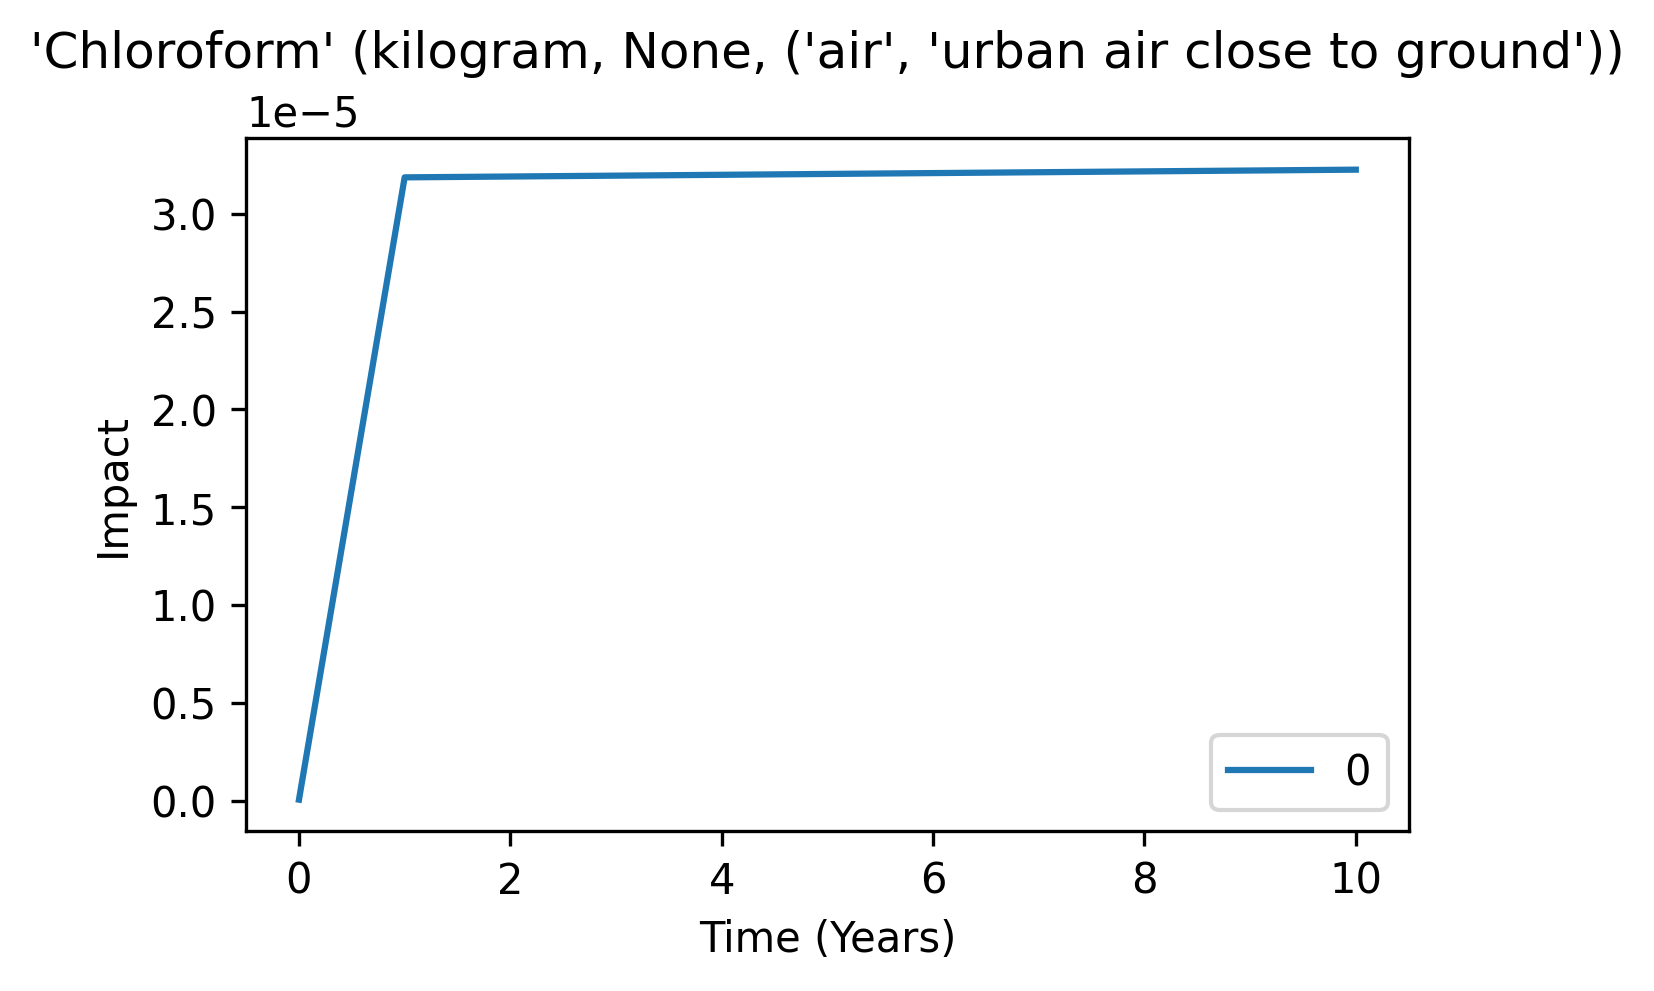

In [65]:
plot_fcf_line_per_flow(my_dict_fcf_flow, ['0'], "'Chloroform' (kilogram, None, ('air', 'urban air close to ground'))", target_dir)

In [66]:
scenario_dict_total_impact_icf = create_scenario_dataframes(my_calculator.total_impact_icf['GWP'], ['GWP100'], scenario_names)

In [67]:
my_dict_icf_flow = map_fcf_icf_results_to_flows(my_lca.biosphere_dict['Main process'], scenario_names, my_calculator.total_impact_icf_per_flow['GWP'])

In [68]:
scenario_dict_total_impact_icf

{'0':        GWP100
 0    0.006949
 1   64.185104
 2   71.316820
 3   78.086641
 4   84.560280
 ..        ...
 95  32.609417
 96  32.523716
 97  32.439470
 98  32.356643
 99  32.275198
 
 [100 rows x 1 columns]}

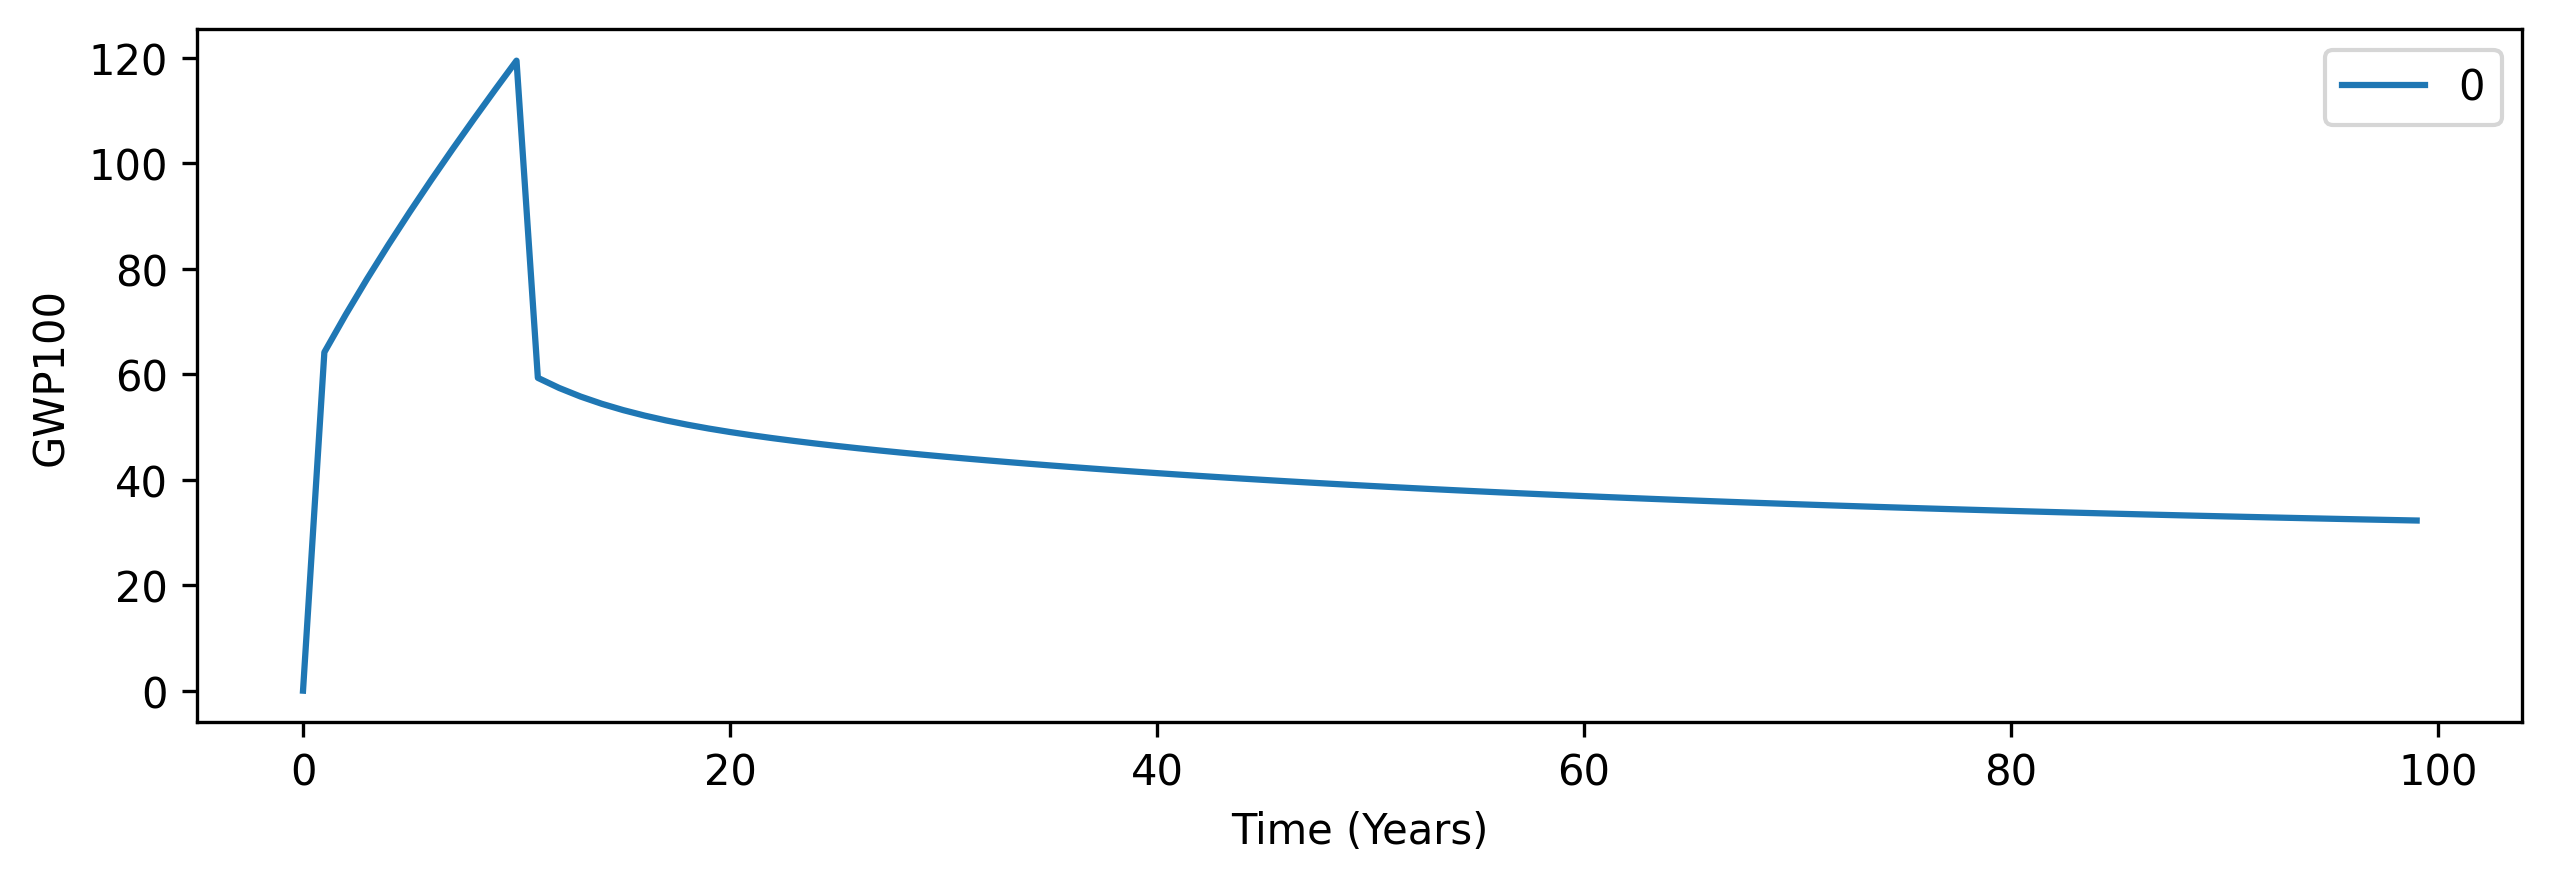

In [69]:
plot_icf_line(scenario_dict_total_impact_icf, ['0'], target_dir, years_to_plot=100, category_name='GWP', figsize = (10,3), dpi=300)

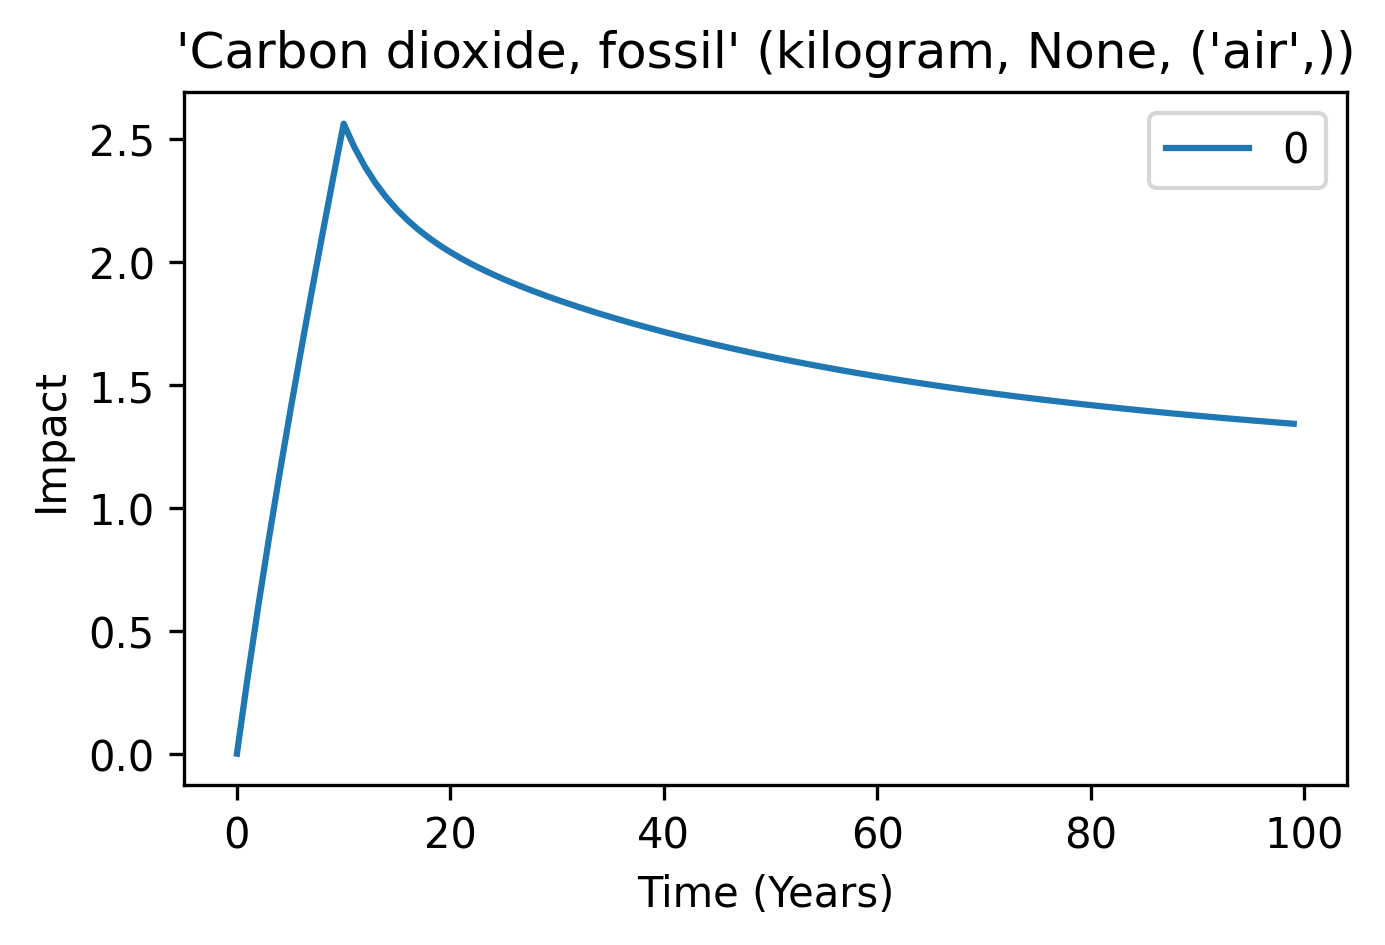

In [70]:
plot_icf_line_per_flow(my_dict_icf_flow, ['0'], "'Carbon dioxide, fossil' (kilogram, None, ('air',))", target_dir, years_to_plot= 100)

In [71]:
flow_to_plot = "sum"
flow_list = ["'Carbon dioxide, fossil' (kilogram, None, ('air', 'non-urban air or from high stacks'))", "'Carbon dioxide, fossil' (kilogram, None, ('air', 'non-urban air or from high stacks'))", "'Carbon dioxide, fossil' (kilogram, None, ('air', 'non-urban air or from high stacks'))", "'Carbon dioxide, fossil' (kilogram, None, ('air', 'non-urban air or from high stacks'))"]
scen_list = ['0']
x = sum_scenarios_per_flow(my_dict_icf_flow, flow_list, scen_list, flow_to_plot)

# The main process as a sub-process

The infrastructural and operational sub-processes of the previous (externally calculated) process need to be included separately in the new main process,
because we need to respect the sequence infrastructural sub-processes - operational sub-processes when modelling these in dictionaries.

As in the previous examples, we first define the new sub-processes and then we will append the externally calculated sub-process (in this case the chemical production modelled above).

In [72]:
number_of_infrastructure_processes_2 = 2
construction_years_2 = 1

In [73]:
keys_chemical_production_infrastructure = {
'Chemical production infrastructure': ''
}
exchange_list_chemical_production_infrastructure = [
np.full((scenarios, construction_years_2),1.)
]

In [74]:
key_chemical_production_operation = {
'Chemical production': ''
}
exchange_list_chemical_production_operation = [
np.full((scenarios, timeframe//time_step),1.)
]

In [75]:
keys_infrastructure_new_main_process = {
    'Building' : 'bw_key_pointing_to_relevant_process'
}

infrastructure2_exchanges_amounts_2 = [np.full((scenarios, construction_years_2),1.)]

In [76]:
keys_other_sub_process = {
'butanol': 'bw_key_pointing_to_relevant_process',
'other chemical': 'bw_key_pointing_to_relevant_process'
}
# We consider the same amounts with before just for demonstration purposes
other_sub_process_exchanges_amounts =[
    butanol_consumption,
    other_chemical_consumption,
]

In [77]:
keys_total_new_main_process = {
'Infrastructure (2)': '',
'Other sub-process' :  ''
}

total_exchanges_new_main_process = [
1./(50*50000*1000) * np.full((scenarios, timeframe // time_step),1.),
np.full((scenarios, timeframe // time_step),1.),
]

In [78]:
key_list_production_new_main_process = [keys_infrastructure_new_main_process, keys_other_sub_process]
exchanges_list_production_new_main_process = [infrastructure2_exchanges_amounts_2, other_sub_process_exchanges_amounts]

We continue as usual until we calculate the unit impact and inventory per sub-sub-process ncluded in each sub-process

In [79]:
mapping_new_main_process = create_mapping(keys_total_new_main_process, key_list_production_new_main_process)

In [80]:
unique_activities_new_main_process = create_list_with_unique_activities(key_list_production_new_main_process)

In [81]:
mapping_exch_new_main_process = create_mapping(keys_total_new_main_process, exchanges_list_production_new_main_process)

In [82]:
my_lca_new_main_process = mpLCAer(6, methods_gp, brightway_configuration_dictionary)

In [83]:
my_lca_new_main_process.import_isolated_environment()

In [84]:
my_lca_new_main_process.lca_calculations(mapping_new_main_process)

We then continue to scale the unit inventories and characterized inventories of each sub-sub-process with the exchange amounts required in each sub-process

In [85]:
my_lca_new_main_process.derive_technosphere_and_biosphere_dictionaries(mapping_new_main_process, "New main process")

All biosphere dictionaries are the same
All technosphere dictionaries are the same


In [86]:
store_dictionaries(my_lca_new_main_process.biosphere_dict['New main process'], target_dir, 'Biosphere_Flows_new_main_process.xlsx')
store_dictionaries(my_lca_new_main_process.technosphere_dict['New main process'], target_dir, 'Technosphere_Flows_new_main_process.xlsx')

In [87]:
my_calculator_new_main_process = fast_calculator()

In [88]:
my_calculator_new_main_process.sum_inventory_per_sub_sub_process(my_lca_new_main_process.unit_inventory)

In [89]:
my_calculator_new_main_process.sum_characterized_inventory_per_sub_sub_process(my_lca_new_main_process.unit_char_inventory)

In [90]:
my_calculator_new_main_process.emissions_calculation_in_time(mapping_exch_new_main_process, my_calculator_new_main_process.summed_unit_inventories)

At this point we need to append the information for the externally calculated sub-processes. We need to include infrastructural sub-processes at the start of the dictionaries and lists and operational sub-process at the end. We use OrderedDict for this.

Next, we make nine appends as explained in the below cells.

In [91]:
from collections import OrderedDict

my_calculator_new_main_process.inventory = OrderedDict(my_calculator_new_main_process.inventory)
my_calculator_new_main_process.inventory_per_process = OrderedDict(my_calculator_new_main_process.inventory_per_process)

First we append the inventory dictionary (holding the unit inventory of the sub-processes) with the unit_inventory of the infrastructural sub-processes that have been pre-calculated

In [92]:
my_calculator_new_main_process.inventory['Chemical production infrastructure'] = my_calculator.total_inventory_infr['Main process']
my_calculator_new_main_process.inventory.move_to_end('Chemical production infrastructure', last=False)

Second we append the inventory dictionary (holding the unit inventory of the sub-processes) with the unit_inventory of the operational sub-processes that have been pre-calculated

In [93]:
my_calculator_new_main_process.inventory['Chemical production'] = my_calculator.total_inventory_op['Main process']

Third we append the inventory_per_process dictionary (holding the unit inventory of the sub-processes per sub-sub-process) with the unit_inventory of the infrastructural sub-processes that have been pre-calculated and with the unit_inventory of the operational sub-processes that have been pre-calculated


In [94]:
my_calculator_new_main_process.inventory_per_process['Chemical production infrastructure'] = my_calculator.total_inventory_infr['Main process'].reshape(1, my_calculator.total_inventory_infr['Main process'].shape[0], scenarios, construction_years)
my_calculator_new_main_process.inventory_per_process.move_to_end('Chemical production infrastructure', last=False)

my_calculator_new_main_process.inventory_per_process['Chemical production'] = my_calculator.total_inventory_op['Main process']

Forth we append the mapping dictionary:

In [95]:
mapping_new_main_process = OrderedDict(mapping_new_main_process)
mapping_new_main_process['Chemical production infrastructure'] = ['']
mapping_new_main_process.move_to_end('Chemical production infrastructure', last=False)

mapping_new_main_process['Chemical production'] = ['']

Fifth we append the mapping_exchanges_dictionary:

In [96]:
mapping_exch_new_main_process = OrderedDict(mapping_exch_new_main_process)
mapping_exch_new_main_process['Chemical production infrastructure'] = [np.full((scenarios, construction_years_2),1.)]
mapping_exch_new_main_process.move_to_end('Chemical production infrastructure', last=False)

mapping_exch_new_main_process['Chemical production'] = [np.full((scenarios, timeframe//time_step),1.)]

Sixth we append the key_list_production_new_main_process list that holds the mapping dicitonaries for each sub-process

In [97]:
key_list_production_new_main_process.insert(0, {'Chemical Production': ''})
key_list_production_new_main_process.append({'Chemical Production': ''})

Seventh we append the exchanges_list_production_new_main_process list that holds the exchanges amounts in lists for each each sub-process. We do not need to do that in principle, since we have already appended the required in the mapping_exch_new_main_process dictionary, but we do it for consistency and for better inspection


In [98]:
exchanges_list_production_new_main_process.insert(0, [np.full((scenarios, construction_years_2),1.)])
exchanges_list_production_new_main_process.append([np.full((scenarios, timeframe//time_step),1.)])

Eighth we append the keys dictionary of the new main process

In [99]:
keys_total_new_main_process = OrderedDict(keys_total_new_main_process)
keys_total_new_main_process['Chemical production infrastructure'] = ''
keys_total_new_main_process.move_to_end('Chemical production infrastructure', last=False)

keys_total_new_main_process['Chemical production'] = ''

Ninth we append the exchanges list of the new main process

In [100]:
total_exchanges_new_main_process.insert(0, 1./(50*50000*1000) * np.full((scenarios, timeframe//time_step),1.))
total_exchanges_new_main_process.append(1. * np.full((scenarios, timeframe//time_step),1.))

The rest of the analysis uses the exact same functions as the original example (beginning of this notebook). A functional unit should be set also (if desired and the modelling should be made with caution to represent the problem to be solved.

In [101]:
my_calculator_new_main_process.emissions_calculation_in_time_total(total_exchanges_new_main_process, my_calculator_new_main_process.inventory, number_of_infrastructure_processes_2, construction_years, "New main process" )

In [102]:
my_calculator_new_main_process.calculation_dynamic_LCIA_fcf(my_calculator_new_main_process.total_inventory['New main process'],
                                                        dyn_factors_gwp_100_fcf, 'GWP')

In [103]:
my_calculator_new_main_process.calculation_dynamic_LCIA_icf(my_calculator_new_main_process.total_inventory['New main process'],
                                                        dyn_factors_gwp_100_icf, 'GWP')

In [104]:
my_calculator_new_main_process.calculate_total_impact_per_category_and_scenario_fcf('GWP')

In [105]:
my_calculator_new_main_process.calculate_total_fu_per_scenario(total_fu, 'New main process')

In [106]:
my_calculator_new_main_process.per_fu_per_category_per_scenario_fcf('GWP', 'New main process')

In [107]:
my_calculator_new_main_process.calculation_of_the_in_time_impact_evolution_absolute_fcf('GWP')

In [108]:
my_calculator_new_main_process.cum_calculation_of_the_in_time_impact_evolution_per_fu_actual_fcf('GWP', construction_years, 'New main process')

In [109]:
scenario_names = [str(i) for i in range(scenarios)]
dict_total_impact_fcf_new_main_process = create_scenario_dataframes(my_calculator_new_main_process.total_impact_fcf['GWP'], ['GWP100'],
                                                            scenario_names)

In [110]:
dict_total_impact_per_fu_fcf_new_main_process = create_scenario_dataframes(
    my_calculator_new_main_process.cum_impact_in_time_per_fu_fcf['GWP'], ['GWP100'], scenario_names)

In [111]:
scenario_dict_cum_impact_fcf_new_main_process = create_scenario_dataframes(my_calculator_new_main_process.cum_impact_in_time_fcf['GWP'],
                                                                   ['GWP100'], scenario_names)

In [112]:
df_impact_per_category_and_scenario_fcf_gwp_new_main_process = create_and_save_dataframes_per_scenario_and_per_category(
    my_calculator_new_main_process.total_impact_per_category_and_scenario_fcf['GWP'], ['GWP'],
    os.path.join(target_dir, 'impact_per_category_per_scenario_fcf_gwp_new_main_process.xlsx'))

Dataframes not save, set save to True to save them


In [113]:
df_impact_per_fu_category_and_scenario_fcf_gwp_new_main_process = create_and_save_dataframes_per_scenario_and_per_category(
    my_calculator_new_main_process.total_impact_per_fu_per_category_per_scenario_fcf['GWP'], ['GWP'],
    os.path.join(target_dir, 'impact_per_fu_category_per_scenario_fcf_new_main_process.xlsx'))

Dataframes not save, set save to True to save them


In [114]:
dataframes_total_impact_fcf_gwp_new_main_process = create_and_save_dataframes_time_series(
    my_calculator_new_main_process.total_impact_fcf['GWP'], ['GWP'], scenario_names,
    excel_file_name=os.path.join(target_dir, 'impacts_time_series_fcf_gwp_new_main_process.xlsx'))

Dataframes not save, set save to True to save them


In [115]:
dataframes_cum_impact_fcf_gwp_new_main_process = create_and_save_dataframes_time_series(
    my_calculator_new_main_process.cum_impact_in_time_fcf['GWP'], ['GWP'], scenario_names,
    excel_file_name=os.path.join(target_dir, 'cum_impacts_time_series_fcf_gwp_new_main_process.xlsx'))

Dataframes not save, set save to True to save them


In [116]:
dataframes_cum_impact_per_fu_fcf_gwp_new_main_process = create_and_save_dataframes_time_series(
    my_calculator_new_main_process.cum_impact_in_time_per_fu_fcf['GWP'], ['GWP'], scenario_names,
    excel_file_name=os.path.join(target_dir, 'cum_impacts_per_fu_time_series_fcf_gwp_new_main_process.xlsx'))

Dataframes not save, set save to True to save them


In [117]:
store_scenario_results(df_impact_per_category_and_scenario_fcf_gwp_new_main_process, target_dir, method_units_list, (5, 3), 300,
                       'New main process FCF')

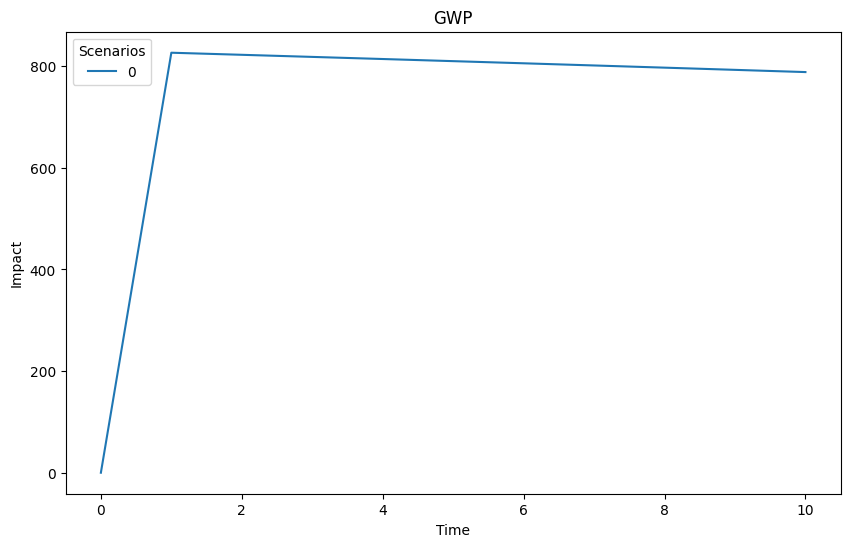

In [118]:
dict_total_impact_per_category_fcf_gwp_new_main_process = visualize_dict_lineplots(dataframes_total_impact_fcf_gwp_new_main_process,
                                                                           ['GWP'], target_dir, keys_to_plot=['GWP'],
                                                                           scenarios_to_plot=['0'],
                                                                           name='FCF_gwp_new_main_process')

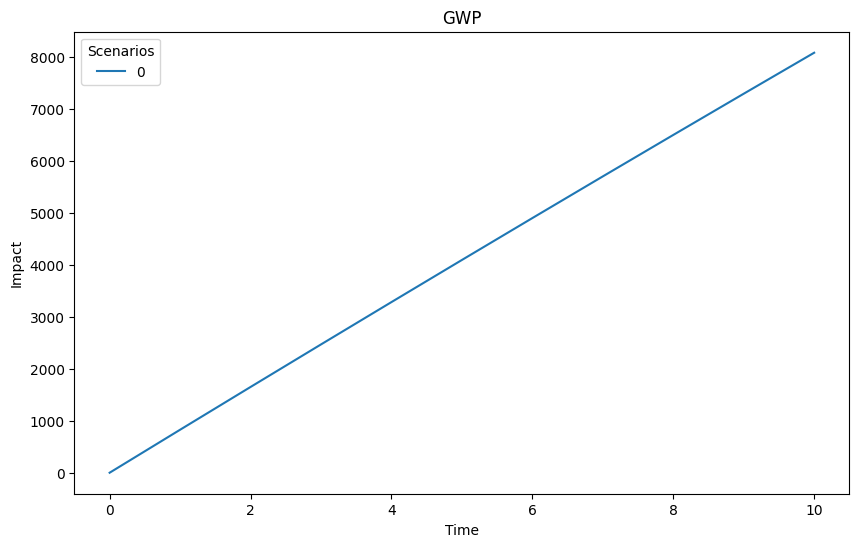

In [119]:
dict_cum_impact_per_category_fcf_gwp_new_main_process = visualize_dict_lineplots(dataframes_cum_impact_fcf_gwp_new_main_process,
                                                                         ['GWP'], target_dir, keys_to_plot=['GWP'],
                                                                         scenarios_to_plot=['0'],
                                                                         name='FCF_gwp_new_main_process')

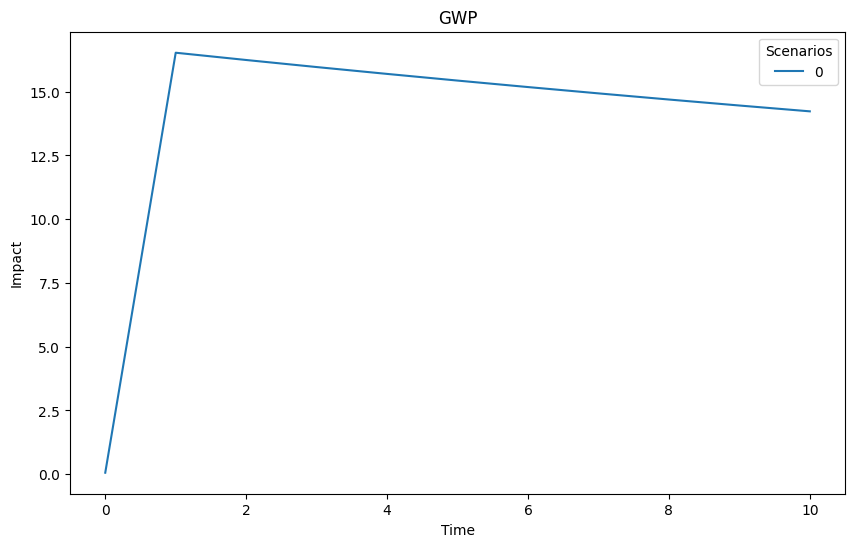

In [120]:
dict_cum_impact_per_fu_per_category_fcf_gwp_new_main_process = visualize_dict_lineplots(
    dataframes_cum_impact_per_fu_fcf_gwp_new_main_process, ['GWP'], target_dir, keys_to_plot=['GWP'], scenarios_to_plot=['0'],
    name='FCF_gwp_new_main_process')

In [121]:
scenario_dict_total_impact_fcf_gwp_new_main_process = create_scenario_dataframes(my_calculator_new_main_process.total_impact_fcf['GWP'],
                                                                         ['GWP'], scenario_names)

In [122]:
plot_bar_charts_by_category(dict_total_impact_fcf_new_main_process, scenarios_to_plot=['0'], impacts_to_plot=['GWP100'],
                            target_dir=target_dir, name='fcf_gwp_new_main_process')

In [123]:
my_dict_fcf_flow_new_main_process = map_fcf_icf_results_to_flows(my_lca_new_main_process.biosphere_dict['New main process'],
                                                         scenario_names,
                                                         my_calculator_new_main_process.total_impact_fcf_per_flow['GWP'])

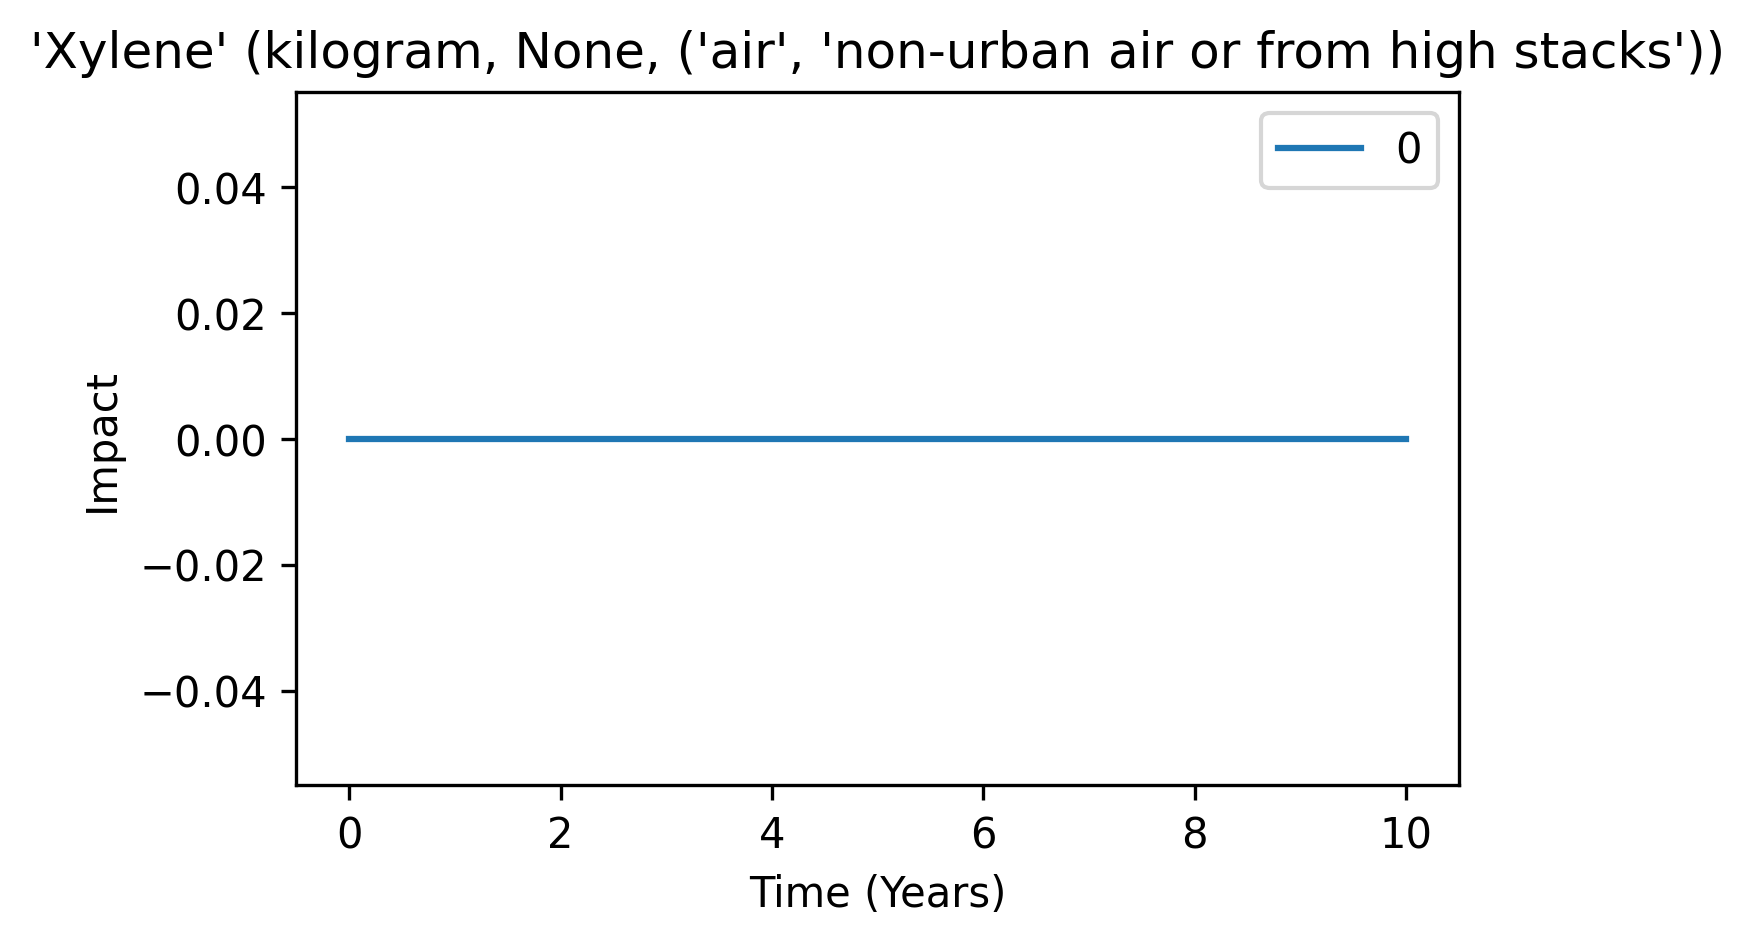

In [131]:
plot_fcf_line_per_flow(my_dict_fcf_flow_new_main_process, ['0'],
                       "'Xylene' (kilogram, None, ('air', 'non-urban air or from high stacks'))", target_dir)

In [132]:
scenario_dict_total_impact_icf_new_main_process = create_scenario_dataframes(my_calculator_new_main_process.total_impact_icf['GWP'],
                                                                     ['GWP100'], scenario_names)

In [133]:
my_dict_icf_flow_new_main_process = map_fcf_icf_results_to_flows(my_lca_new_main_process.biosphere_dict['New main process'],
                                                         scenario_names,
                                                         my_calculator_new_main_process.total_impact_icf_per_flow['GWP'])

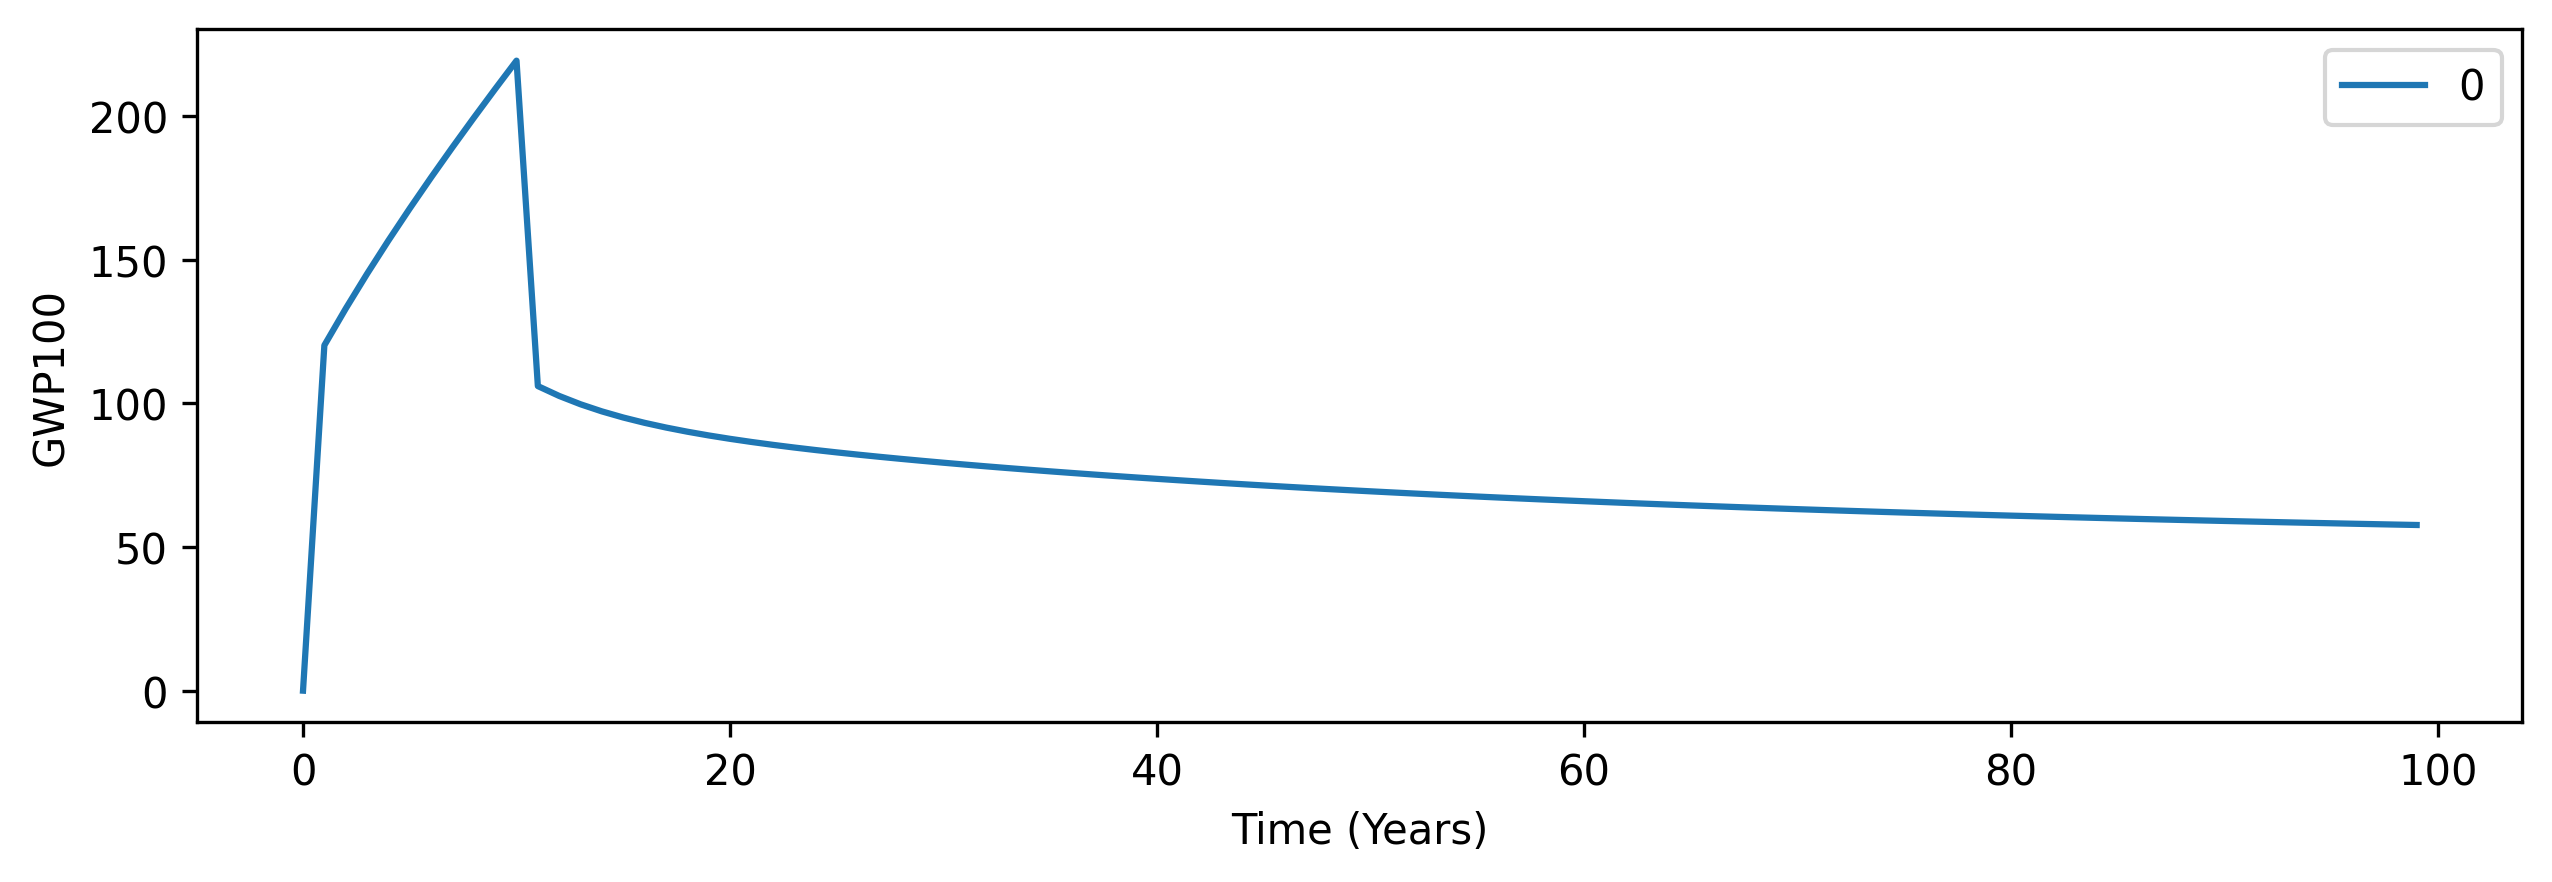

In [134]:
plot_icf_line(scenario_dict_total_impact_icf_new_main_process, ['0'], target_dir, years_to_plot=100, category_name='GWP',
              figsize=(10, 3), dpi=300)


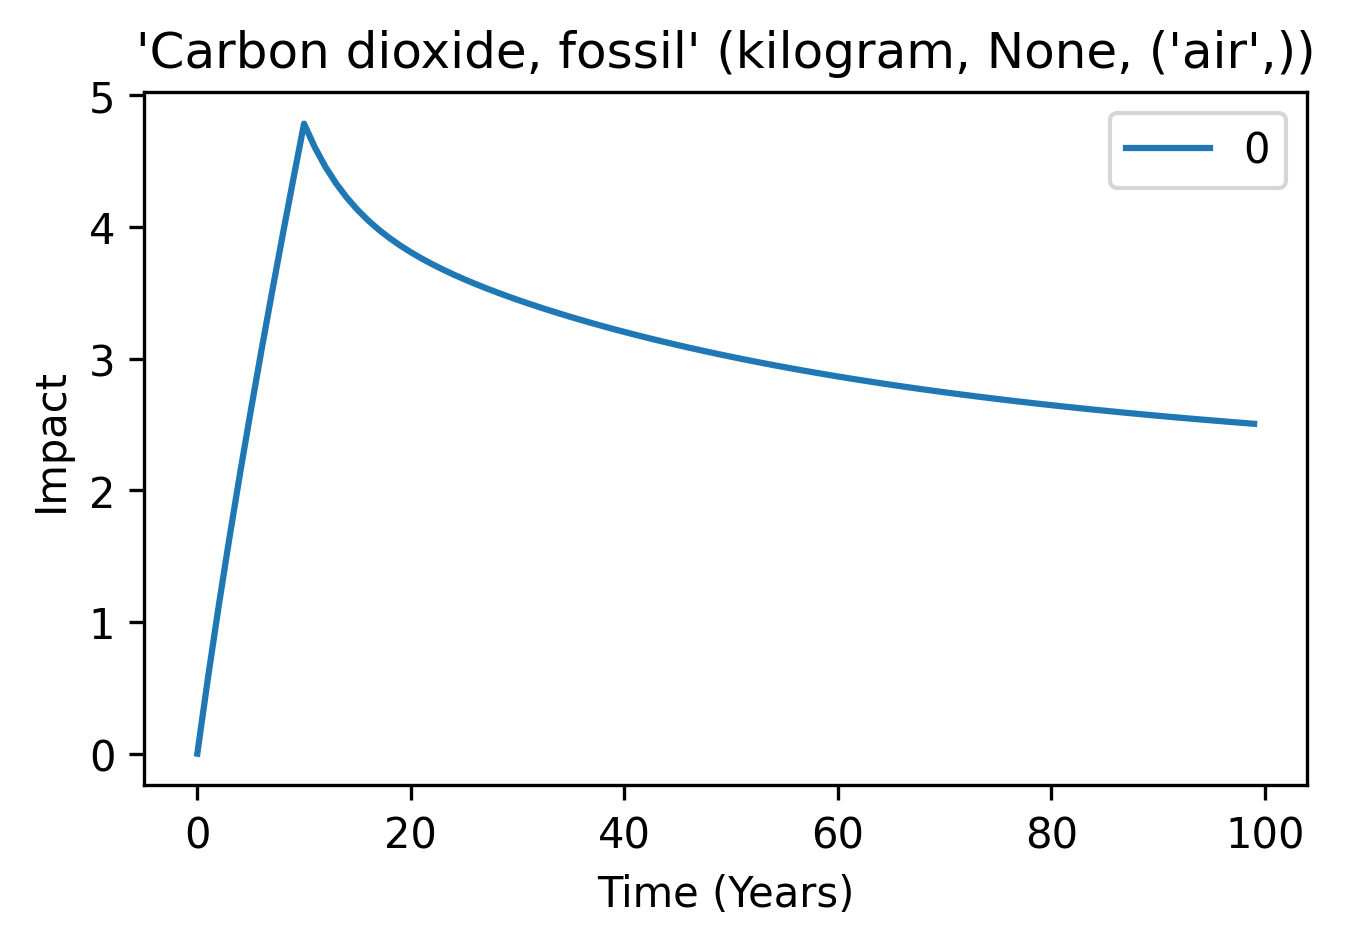

In [135]:
plot_icf_line_per_flow(my_dict_icf_flow_new_main_process, ['0'], "'Carbon dioxide, fossil' (kilogram, None, ('air',))",
                       target_dir, years_to_plot=100)

In [136]:
flow_to_plot = "test"
flow_list = ["'Carbon dioxide, fossil' (kilogram, None, ('air', 'non-urban air or from high stacks'))",
             "'Carbon dioxide, fossil' (kilogram, None, ('air', 'non-urban air or from high stacks'))",
             "'Carbon dioxide, fossil' (kilogram, None, ('air', 'non-urban air or from high stacks'))",
             "'Carbon dioxide, fossil' (kilogram, None, ('air', 'non-urban air or from high stacks'))"]
scen_list = ['0']
x = sum_scenarios_per_flow(my_dict_icf_flow_new_main_process, flow_list, scen_list, flow_to_plot)

In [137]:
x

{'test':              0
 0     0.002392
 1    28.740508
 2    55.746319
 3    81.339374
 4   105.774029
 ..         ...
 95  125.415623
 96  125.086041
 97  124.762056
 98  124.443526
 99  124.130310
 
 [100 rows x 1 columns]}